# Multimodal LLMs for Scientific Image QA
### Applied LLMs for Scientists - Video 8
**Author: Sreenivas Bhattiprolu (DigitalSreeni)**

---

## What this notebook does

In the previous videos of this series we focused on **detecting and segmenting** objects in scientific images using text prompts. Models like Grounding DINO, SAM2, and SAM3 take a prompt and find objects visually.

This notebook explores a completely different but equally useful capability: asking a multimodal large language model to **look at an image and answer questions about it in natural language**. No bounding boxes. No masks. Just: show the model an image, ask a question, get a descriptive answer.

This is useful for:
- Quick triage of images before annotation ("does this image contain glomeruli?")
- Generating automated descriptions of experimental results
- Extracting structured observations ("how many objects do you count?")
- Checking stain quality, tissue integrity, or imaging artifacts
- Comparing model responses across different LLMs to understand their domain knowledge

## Models compared

We compare three models on the same scientific images with the same questions:

| Model | Provider | Access |
|-------|----------|--------|
| GPT-4o | OpenAI | API (paid per token) |
| Claude Sonnet | Anthropic | API (paid per token) |
| LLaVA 13B | Meta (via Ollama) | Local, free after download |

## Setup requirements

1. **Google Drive**: mount your drive and store your `.env` file and images there
2. **OpenAI API key**: from platform.openai.com
3. **Anthropic API key**: from console.anthropic.com
4. **LLaVA via Ollama**: running locally on your machine (not in Colab)
   - For the Ollama section, run the cell that calls your local machine's Ollama server
   - If you are running this entirely in Colab without local Ollama, skip that section

Your `.env` file on Google Drive should look like this:
```
OPENAI_API_KEY=sk-...
ANTHROPIC_API_KEY=sk-ant-...
OLLAMA_BASE_URL=http://localhost:11434
```


## Step 1: Mount Google Drive and load API keys

We store our API keys in a `.env` file on Google Drive so they are never hard-coded in the notebook. Mount your drive, point `ENV_PATH` to wherever you placed the file, and we will load the keys from there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Point this to the folder on your drive that contains your .env file
ENV_PATH = '/content/drive/MyDrive/ColabNotebooks/llm_for_scientists/llm_keys/.env'

# Load the .env file manually (no python-dotenv needed)
with open(ENV_PATH) as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            key, value = line.split('=', 1)
            os.environ[key.strip()] = value.strip()

OPENAI_API_KEY    = os.environ.get('OPENAI_API_KEY')
ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')
#OLLAMA_BASE_URL   = os.environ.get('OLLAMA_BASE_URL', 'http://localhost:11434')

# Confirm keys loaded (only shows first 8 chars for safety)
print(f'OpenAI key loaded:    {OPENAI_API_KEY[:8]}...'    if OPENAI_API_KEY    else 'OpenAI key NOT found')
print(f'Anthropic key loaded: {ANTHROPIC_API_KEY[:8]}...' if ANTHROPIC_API_KEY else 'Anthropic key NOT found')
# print(f'Ollama URL:           {OLLAMA_BASE_URL}')

OpenAI key loaded:    sk-proj-...
Anthropic key loaded: sk-ant-a...


## Step 2: Install dependencies

We only need the OpenAI and Anthropic Python SDKs. Both have a very similar interface for sending images, which makes the comparison clean and easy to follow.

In [ ]:
!pip install -q openai anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 10.1 MB/s eta 0:00:00


## Step 3: Load and display the image

We will work with kidney histology images the same ones used in the detection experiments.
Point `IMAGE_PATH` to any image on your Google Drive. We display it here so we know exactly what we are sending to each model before we ask questions.

We also convert the image to base64 here, because that is how all three APIs accept image input: as a base64-encoded string embedded in the request.

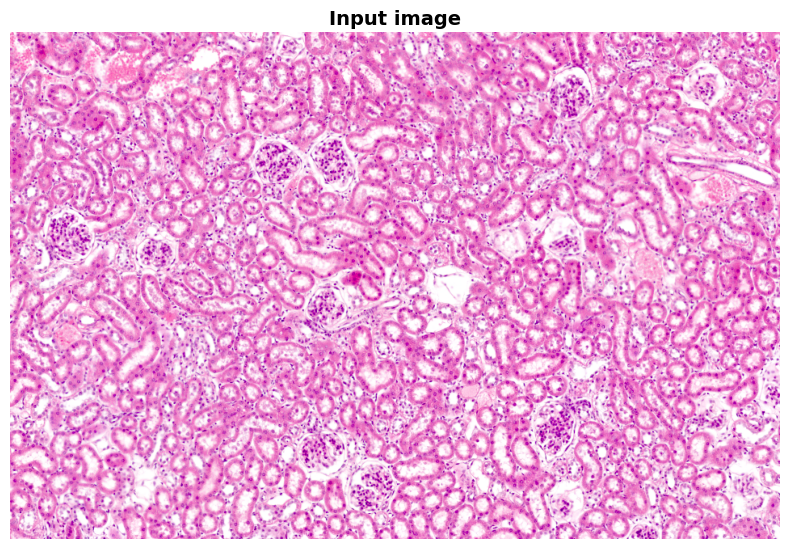

Image size: 953 x 627 pixels
Media type: image/png
Base64 length: 2,007,712 characters
Image ready for API calls.


In [ ]:
import base64
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Point this to your image on Google Drive
IMAGE_PATH = '/content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/rat_kidney_HE_11.png'

# Load and display
image_pil = Image.open(IMAGE_PATH).convert('RGB')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(image_pil)
ax.set_title('Input image', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Image size: {image_pil.size[0]} x {image_pil.size[1]} pixels')

# Convert to base64 for API calls
with open(IMAGE_PATH, 'rb') as f:
    IMAGE_B64 = base64.b64encode(f.read()).decode('utf-8')

# Detect media type from extension
ext = IMAGE_PATH.lower().split('.')[-1]
MEDIA_TYPE = 'image/png' if ext == 'png' else 'image/jpeg'

print(f'Media type: {MEDIA_TYPE}')
print(f'Base64 length: {len(IMAGE_B64):,} characters')
print('Image ready for API calls.')

## Step 4: Define the questions

We will ask each model the same set of questions. This keeps the comparison fair.

The questions are designed to probe different kinds of understanding:
- General image description (does the model recognize the domain?)
- Structure identification (does it know what a glomerulus is?)
- Counting (can it estimate object counts?)
- Technical assessment (can it comment on stain quality?)
- Practical guidance (can it suggest next steps?)

Feel free to add your own questions or swap out these for ones relevant to your domain.

In [ ]:
QUESTIONS = [
    'What type of biological image is this? Describe what you see in as much detail as possible.',
    'Can you identify any glomeruli in this image? If yes, describe their appearance and approximate locations.',
    'How many glomeruli do you think are visible in this image? Give your best estimate.',
    'What staining technique does this image appear to use, and what does the staining tell us?',
    'Are there any regions of the tissue that look abnormal or worth noting from a pathology perspective?',
    'If you were to annotate this image for a machine learning dataset, what object classes would you define?',
]

print(f'{len(QUESTIONS)} questions loaded:')
for i, q in enumerate(QUESTIONS, 1):
    print(f'  Q{i}: {q}')

6 questions loaded:
  Q1: What type of biological image is this? Describe what you see in as much detail as possible.
  Q2: Can you identify any glomeruli in this image? If yes, describe their appearance and approximate locations.
  Q3: How many glomeruli do you think are visible in this image? Give your best estimate.
  Q4: What staining technique does this image appear to use, and what does the staining tell us?
  Q5: Are there any regions of the tissue that look abnormal or worth noting from a pathology perspective?
  Q6: If you were to annotate this image for a machine learning dataset, what object classes would you define?


## Step 5: Helper function for displaying responses

We will use this throughout the notebook to display each model's response in a clean, readable format. Each question and answer pair is printed with a separator so the output is easy to read on screen and on camera.

In [ ]:
def display_responses(model_name, questions, answers):
    """Print questions and answers in a clean readable format."""
    print('=' * 70)
    print(f'  MODEL: {model_name}')
    print('=' * 70)
    for i, (q, a) in enumerate(zip(questions, answers), 1):
        print(f'\nQ{i}: {q}')
        print(f'\nA{i}: {a}')
        print('\n' + '-' * 60)
    print()


def display_comparison(question, responses_dict):
    """Display all model answers for a single question side by side."""
    print('=' * 70)
    print(f'QUESTION: {question}')
    print('=' * 70)
    for model_name, answer in responses_dict.items():
        print(f'\n[{model_name}]')
        print(answer)
        print('-' * 60)
    print()

## Step 6: GPT-4o

GPT-4o is OpenAI's flagship multimodal model. It processes text and images through a unified architecture, meaning it does not treat vision as an add-on to a language model but handles both modalities natively.

We send each question as a separate API call so we can see the model's response to each question independently. The image is included in every call as a base64-encoded string.

A typical call with a medium-sized microscopy image costs a few cents at most for the full set of questions.

In [ ]:
from openai import OpenAI

openai_client = OpenAI(api_key=OPENAI_API_KEY)

def ask_gpt4o(question, image_b64, media_type):
    """Send a single question with the image to GPT-4o."""
    response = openai_client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {
                'role': 'user',
                'content': [
                    {
                        'type': 'image_url',
                        'image_url': {
                            'url': f'data:{media_type};base64,{image_b64}',
                            'detail': 'high',
                        }
                    },
                    {
                        'type': 'text',
                        'text': question,
                    }
                ]
            }
        ],
        max_tokens=512,
    )
    return response.choices[0].message.content


print('Querying GPT-4o...')
gpt4o_answers = []
for i, question in enumerate(QUESTIONS, 1):
    print(f'  Sending Q{i}...')
    answer = ask_gpt4o(question, IMAGE_B64, MEDIA_TYPE)
    gpt4o_answers.append(answer)

print('Done.\n')
display_responses('GPT-4o', QUESTIONS, gpt4o_answers)

Querying GPT-4o...
  Sending Q1...
  Sending Q2...
  Sending Q3...
  Sending Q4...
  Sending Q5...
  Sending Q6...
Done.

  MODEL: GPT-4o

Q1: What type of biological image is this? Describe what you see in as much detail as possible.

A1: This image is a histological section of kidney tissue, stained using hematoxylin and eosin (H&E). Here's a detailed description:

1. **Renal Corpuscles**: The image shows multiple round structures, which are the renal corpuscles. These contain the glomeruli, seen as dense clusters of cells due to the filtration membrane and capillary loops.

2. **Tubules**: Surrounding the renal corpuscles are numerous tubules. These appear as circular or elongated structures, delineated by a single row of epithelial cells. The lumen of these tubules can be seen as clear spaces within the rings.

3. **H&E Staining**: 
   - **Hematoxylin** stains the nuclei of cells a deep purple or blue, clearly highlighting the cellular organization.
   - **Eosin** stains the cytopl

## Step 7: Claude Sonnet (Anthropic)

Claude is Anthropic's multimodal model. The API structure is very similar to OpenAI's, which makes it straightforward to run the same experiment. Claude tends to give longer, more structured responses and is often more cautious about making definitive claims when it is uncertain.

We use `claude-sonnet-4-6` here, which is Anthropic's current efficient flagship model and a good balance of capability and cost.

In [ ]:
import anthropic

anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

def ask_claude(question, image_b64, media_type):
    """Send a single question with the image to Claude Sonnet."""
    response = anthropic_client.messages.create(
        model='claude-sonnet-4-6',
        max_tokens=512,
        messages=[
            {
                'role': 'user',
                'content': [
                    {
                        'type': 'image',
                        'source': {
                            'type': 'base64',
                            'media_type': media_type,
                            'data': image_b64,
                        }
                    },
                    {
                        'type': 'text',
                        'text': question,
                    }
                ]
            }
        ]
    )
    return response.content[0].text


print('Querying Claude Sonnet...')
claude_answers = []
for i, question in enumerate(QUESTIONS, 1):
    print(f'  Sending Q{i}...')
    answer = ask_claude(question, IMAGE_B64, MEDIA_TYPE)
    claude_answers.append(answer)

print('Done.\n')
display_responses('Claude Sonnet', QUESTIONS, claude_answers)

Querying Claude Sonnet...
  Sending Q1...
  Sending Q2...
  Sending Q3...
  Sending Q4...
  Sending Q5...
  Sending Q6...
Done.

  MODEL: Claude Sonnet

Q1: What type of biological image is this? Describe what you see in as much detail as possible.

A1: # Histological Analysis: Renal (Kidney) Tissue

## Image Type
This is a **light microscopy histological section** stained with **Hematoxylin and Eosin (H&E)**, showing renal cortex tissue at approximately **medium magnification (10x-20x objective)**.

---

## Detailed Structures Observed

### Renal Tubules (predominant feature)
- **Proximal convoluted tubules (PCT)**: The most abundant structures — characterized by:
  - **Cuboidal to columnar epithelial cells**
  - **Granular, eosinophilic (pink) cytoplasm**
  - **Indistinct luminal borders** (brush border)
  - Round, centrally placed nuclei
- **Distal convoluted tubules (DCT)**: Smaller, with:
  - More **clearly defined lumens**
  - Less eosinophilic cytoplasm
  - More distinct cell bo

## Step 8: LLaVA 13B (local via Ollama)

LLaVA (Large Language and Vision Assistant) is an open-source multimodal model from the University of Wisconsin. Unlike GPT-4o and Claude which run on remote servers, LLaVA runs entirely on your local machine via Ollama. No data leaves your computer, no API costs, and no internet required after the initial download.

To use this section:
1. Make sure Ollama is running on your local machine
2. Make sure you have pulled the model: `ollama pull llava:13b`
3. The `OLLAMA_BASE_URL` in your `.env` file should point to your local machine

If you are running this notebook in Colab and do not have a local Ollama server, you can skip this section or run Ollama inside Colab using the cell below.

Ollama's API accepts images as base64 strings, consistent with the other two models.

Optional

In [ ]:
# # Install zstd first (required by Ollama installer on Colab), then install Ollama
# !sudo apt-get install -y zstd
# !curl -fsSL https://ollama.com/install.sh | sh

# import subprocess, time, requests

# # Start Ollama server in the background
# subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# # Give it a few seconds to start
# time.sleep(8)

# # Confirm it is running
# try:
#     r = requests.get('http://localhost:11434/api/tags', timeout=5)
#     print('Ollama server is running.')
# except Exception as e:
#     print(f'Ollama server not responding: {e}')

# # Pull LLaVA 7B — this will take a few minutes on first run (~4.5 GB download)
# # On subsequent runs in the same Colab session it will skip the download
# !ollama pull llava:7b

# OLLAMA_BASE_URL = 'http://localhost:11434'
# print('Done. OLLAMA_BASE_URL set to', OLLAMA_BASE_URL)

In [ ]:
#!ollama list

Optional

In [ ]:
# import requests
# import json

# LLAVA_MODEL = 'llava:7b'

# def ask_llava(question, image_b64):
#     """Send a single question with the image to LLaVA via Ollama API."""
#     payload = {
#         'model': LLAVA_MODEL,
#         'prompt': question,
#         'images': [image_b64],
#         'stream': False,
#     }
#     response = requests.post(
#         f'{OLLAMA_BASE_URL}/api/generate',
#         json=payload,
#         timeout=600,   # 10 minutes -- first call loads weights into GPU
#     )
#     response.raise_for_status()
#     return response.json()['response']


# # Check Ollama is reachable before sending all questions
# try:
#     health = requests.get(f'{OLLAMA_BASE_URL}/api/tags', timeout=5)
#     available_models = [m['name'] for m in health.json().get('models', [])]
#     print(f'Ollama reachable. Available models: {available_models}')
#     if LLAVA_MODEL not in available_models:
#         print(f'Warning: {LLAVA_MODEL} not found. Run: ollama pull {LLAVA_MODEL}')
#     ollama_available = True
# except Exception as e:
#     print(f'Ollama not reachable: {e}')
#     print('Skipping LLaVA section. Uncomment the Colab install cell above to run Ollama here.')
#     ollama_available = False

Optional

In [ ]:
# llava_answers = []

# if ollama_available:
#     print(f'Querying {LLAVA_MODEL}...')
#     for i, question in enumerate(QUESTIONS, 1):
#         print(f'  Sending Q{i}...')
#         answer = ask_llava(question, IMAGE_B64)
#         llava_answers.append(answer)
#     print('Done.\n')
#     display_responses(f'LLaVA 13B (local)', QUESTIONS, llava_answers)
# else:
#     llava_answers = ['[LLaVA not available]'] * len(QUESTIONS)
#     print('LLaVA answers skipped.')

## Step 9: Side-by-side comparison

Now that we have answers from all three models, let us compare them question by question. This is the most revealing part of the experiment: where do the models agree, where do they disagree, and which one gives the most scientifically useful answer?

We will look at each question in turn and print all three answers together.

In [ ]:
all_answers = {
    'GPT-4o':        gpt4o_answers,
    'Claude Sonnet': claude_answers,
#    'LLaVA 13B':     llava_answers,
}

# Pick which question to compare (change the index to explore others)
# Run this cell multiple times with different question_idx values
question_idx = 0   # 0 to 5

responses_for_question = {
    model: answers[question_idx]
    for model, answers in all_answers.items()
}
display_comparison(QUESTIONS[question_idx], responses_for_question)

QUESTION: What type of biological image is this? Describe what you see in as much detail as possible.

[GPT-4o]
This image is a histological section of kidney tissue, stained using hematoxylin and eosin (H&E). Here's a detailed description:

1. **Renal Corpuscles**: The image shows multiple round structures, which are the renal corpuscles. These contain the glomeruli, seen as dense clusters of cells due to the filtration membrane and capillary loops.

2. **Tubules**: Surrounding the renal corpuscles are numerous tubules. These appear as circular or elongated structures, delineated by a single row of epithelial cells. The lumen of these tubules can be seen as clear spaces within the rings.

3. **H&E Staining**: 
   - **Hematoxylin** stains the nuclei of cells a deep purple or blue, clearly highlighting the cellular organization.
   - **Eosin** stains the cytoplasm and extracellular matrix, giving the tissue a pink appearance.

4. **Cellular Details**: Within the renal corpuscles and tub

In [ ]:
# Print all questions compared across all models
for i, question in enumerate(QUESTIONS):
    responses_for_question = {
        model: answers[i]
        for model, answers in all_answers.items()
    }
    display_comparison(question, responses_for_question)

## Step 10: Structured output extraction

The free-text responses above are useful for understanding what each model knows, but for practical workflows we often want structured output: a dictionary or JSON object we can process programmatically.

Here we ask each model to return a structured summary of the image: tissue type, stain, structures identified, estimated object count, and any quality concerns. We instruct the model to respond in JSON format so we can parse and compare the results.

This is a common pattern when using multimodal LLMs in real pipelines, for example to auto-populate a metadata database or trigger downstream processing based on image content.

In [ ]:
import json
import re

STRUCTURED_PROMPT = """Analyze this scientific image and return a JSON object with exactly these fields:
{
  "tissue_type": "<what tissue or sample type is shown>",
  "stain": "<staining technique used>",
  "structures_identified": ["<list of distinct structures you can see>"],
  "glomeruli_count_estimate": <integer or null if none visible>,
  "image_quality": "<good / acceptable / poor>",
  "quality_notes": "<any artifacts, out-of-focus regions, or concerns>",
  "suitable_for_ml_annotation": <true or false>
}
Return only the JSON object. No explanation, no markdown code fences."""


def extract_json(text):
    """Try to parse JSON from model response, handling common formatting issues."""
    # Strip markdown code fences if present
    text = re.sub(r'```json|```', '', text).strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {'raw_response': text, 'parse_error': 'Could not parse JSON'}


print('Requesting structured output from each model...\n')

structured_results = {}

# GPT-4o
print('GPT-4o...')
raw_gpt4o  = ask_gpt4o(STRUCTURED_PROMPT, IMAGE_B64, MEDIA_TYPE)
structured_results['GPT-4o'] = extract_json(raw_gpt4o)

# Claude
print('Claude Sonnet...')
raw_claude = ask_claude(STRUCTURED_PROMPT, IMAGE_B64, MEDIA_TYPE)
structured_results['Claude Sonnet'] = extract_json(raw_claude)

# # LLaVA
# if ollama_available:
#     print('LLaVA 13B...')
#     raw_llava  = ask_llava(STRUCTURED_PROMPT, IMAGE_B64)
#     structured_results['LLaVA 13B'] = extract_json(raw_llava)

print('\nStructured results:\n')
for model, result in structured_results.items():
    print(f'[{model}]')
    print(json.dumps(result, indent=2))
    print()

Requesting structured output from each model...

GPT-4o...
Claude Sonnet...

Structured results:

[GPT-4o]
{
  "tissue_type": "kidney",
  "stain": "Hematoxylin and Eosin (H&E)",
  "structures_identified": [
    "glomeruli",
    "tubules",
    "vascular structures"
  ],
  "glomeruli_count_estimate": 10,
  "image_quality": "good",
  "quality_notes": "No notable artifacts or out-of-focus regions",
  "suitable_for_ml_annotation": true
}

[Claude Sonnet]
{
  "tissue_type": "Kidney cortex",
  "stain": "Hematoxylin and Eosin (H&E)",
  "structures_identified": [
    "Glomeruli",
    "Proximal convoluted tubules",
    "Distal convoluted tubules",
    "Collecting ducts",
    "Bowman's capsule",
    "Peritubular capillaries",
    "Interstitium",
    "Small blood vessels"
  ],
  "glomeruli_count_estimate": 12,
  "image_quality": "good",
  "quality_notes": "Minimal artifacts present. Tissue is well-preserved with uniform staining. Slight variation in eosin intensity in some regions but overall cris

## Step 11: Visualize structured results

Let us display the structured output as a comparison table alongside the original image. This gives a clean view of where the models agree and disagree on factual questions like tissue type, stain, and object count.

This is the kind of output you would use in a real pipeline to quickly triage a batch of images.

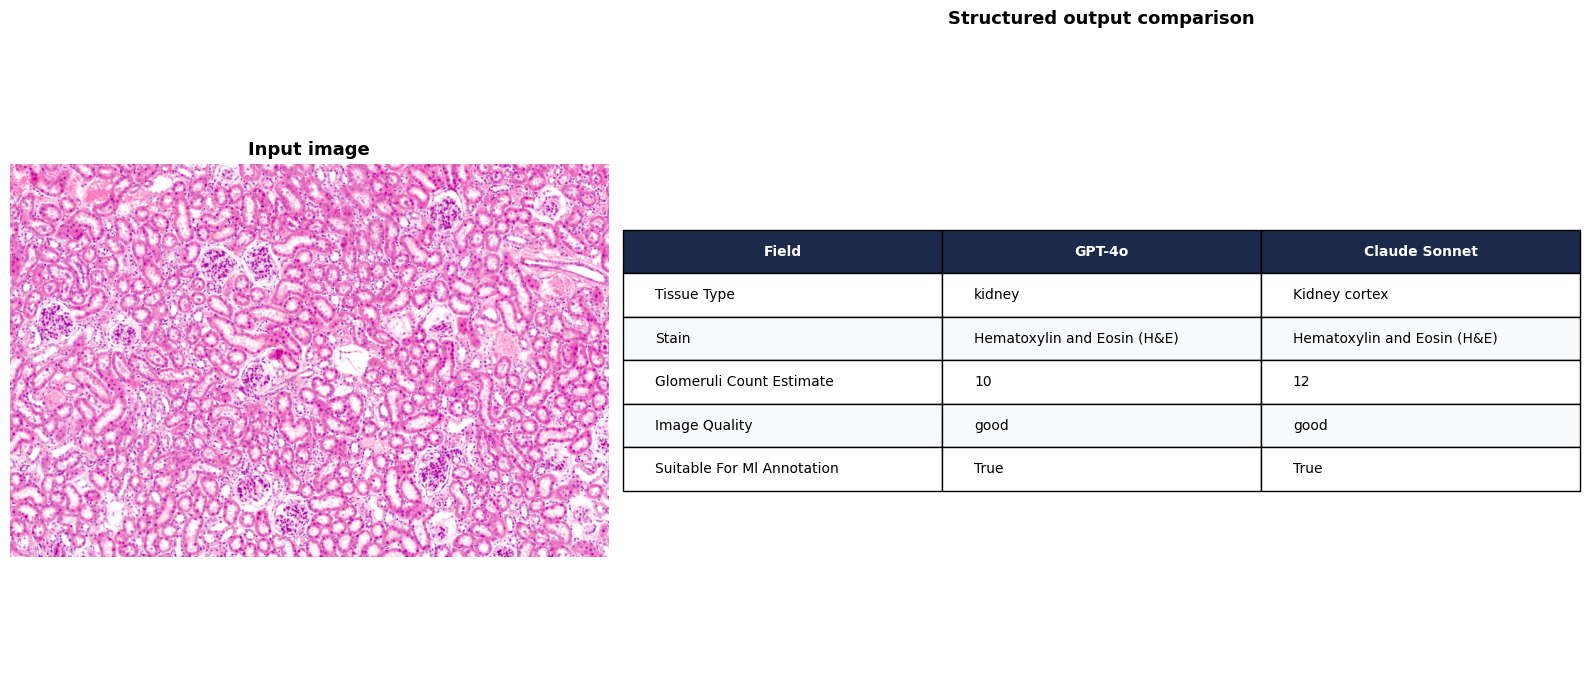

Figure saved as model_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fields_to_show = [
    'tissue_type',
    'stain',
    'glomeruli_count_estimate',
    'image_quality',
    'suitable_for_ml_annotation',
]

models = list(structured_results.keys())

fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], figure=fig)

# Left: original image
ax_img = fig.add_subplot(gs[0])
ax_img.imshow(image_pil)
ax_img.set_title('Input image', fontsize=13, fontweight='bold')
ax_img.axis('off')

# Right: comparison table
ax_tbl = fig.add_subplot(gs[1])
ax_tbl.axis('off')

col_labels = ['Field'] + models
table_data = []
for field in fields_to_show:
    row = [field.replace('_', ' ').title()]
    for model in models:
        val = structured_results.get(model, {}).get(field, 'N/A')
        row.append(str(val))
    table_data.append(row)

tbl = ax_tbl.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='left',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.2)

# Style header row
for col in range(len(col_labels)):
    tbl[(0, col)].set_facecolor('#1B2A4A')
    tbl[(0, col)].set_text_props(color='white', fontweight='bold')

# Alternating row shading
for row in range(1, len(table_data) + 1):
    bg = '#F8FAFC' if row % 2 == 0 else '#FFFFFF'
    for col in range(len(col_labels)):
        tbl[(row, col)].set_facecolor(bg)

ax_tbl.set_title('Structured output comparison', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as model_comparison.png')

## Step 12: Batch processing for image triage

Now that we have tested our models on a single image and seen how they compare,
we move to something practically useful: running the same analysis across a folder
of images automatically.

The goal here is image triage. For each image we want to know:
- Does it contain glomeruli?
- If yes, roughly how many?
- How confident is the model in that assessment?

We use a tightly structured prompt that forces the model to return a consistent
JSON object for every image. This makes the output easy to process programmatically
and sets us up for the next video where we will take action based on these results.

We use GPT-4o for batch processing here because in our head-to-head comparison it
gave the most consistent structured output. Swap in `ask_claude` if your results
showed otherwise.

Point `IMAGE_FOLDER` to your folder on Google Drive before running.

In [ ]:
import os
import json
import re
import base64
import pandas as pd
from pathlib import Path

# Point to your image folder on Google Drive
IMAGE_FOLDER = '/content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/'

SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff'}

image_files = sorted([
    p for p in Path(IMAGE_FOLDER).iterdir()
    if p.suffix.lower() in SUPPORTED_EXTS
])

print(f'Found {len(image_files)} image(s) in {IMAGE_FOLDER}')
for p in image_files:
    print(f'  {p.name}')

# Triage prompt — structured and strict so JSON parsing is reliable
TRIAGE_PROMPT = """Analyze this scientific histology image and return a JSON object with exactly these fields:
{
  "has_glomeruli": <true or false>,
  "glomeruli_count_estimate": <integer, or 0 if none visible>,
  "confidence": "<high, medium, or low>",
  "confidence_reason": "<one sentence explaining your confidence level>",
  "tissue_type": "<brief description of tissue>",
  "stain": "<staining technique if identifiable, or unknown>"
}

Rules:
- has_glomeruli must be true only if you can clearly identify at least one glomerulus
- confidence should be high if structures are clearly visible, medium if uncertain, low if the image is ambiguous or quality is poor
- Return only the JSON object, no explanation, no markdown code fences

"""

Found 11 image(s) in /content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/
  no_glom_HE1.png
  no_glom_HE2.png
  no_glom_IHC1.png
  rat_kidney_HE_1.png
  rat_kidney_HE_10.png
  rat_kidney_HE_11.png
  rat_kidney_HE_8.png
  rat_kidney_IHC_1.png
  rat_kidney_IHC_10.png
  rat_kidney_IHC_11.png
  rat_kidney_IHC_8.png


In [ ]:
def encode_image(img_path):
    """Load an image file and return base64 string and media type."""
    with open(img_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode('utf-8')
    mtype = 'image/png' if img_path.suffix.lower() == '.png' else 'image/jpeg'
    return b64, mtype


def extract_json(text):
    """Parse JSON from model response, stripping markdown fences if present."""
    text = re.sub(r'```json|```', '', text).strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {'parse_error': 'Could not parse JSON', 'raw': text[:200]}


def run_triage(img_path, model='gpt4o'):
    """Run triage on a single image and return the parsed result dict."""
    b64, mtype = encode_image(img_path)
    try:
        if model == 'gpt4o':
            raw = ask_gpt4o(TRIAGE_PROMPT, b64, mtype)
        else:
            raw = ask_claude(TRIAGE_PROMPT, b64, mtype)
        result = extract_json(raw)
    except Exception as e:
        result = {
            'has_glomeruli':          None,
            'glomeruli_count_estimate': None,
            'confidence':             'error',
            'confidence_reason':      str(e),
            'tissue_type':            None,
            'stain':                  None,
        }
    result['filename'] = img_path.name
    result['model']    = model
    return result


# Run triage on all images
# Change model='claude' to use Claude instead
print('Running triage...\n')
triage_records = []

for img_path in image_files:
    print(f'  Processing {img_path.name}...', end=' ')
    record = run_triage(img_path, model='claude')   # 'gpt4o' or 'claude'
    triage_records.append(record)
    has = record.get('has_glomeruli')
    count = record.get('glomeruli_count_estimate', 0)
    conf = record.get('confidence', 'unknown')
    print(f'glomeruli={has}  count={count}  confidence={conf}')

print(f'\nDone. {len(triage_records)} image(s) processed.')

Running triage...

  Processing no_glom_HE1.png... glomeruli=False  count=0  confidence=high
  Processing no_glom_HE2.png... glomeruli=False  count=0  confidence=high
  Processing no_glom_IHC1.png... glomeruli=False  count=0  confidence=high
  Processing rat_kidney_HE_1.png... glomeruli=True  count=18  confidence=high
  Processing rat_kidney_HE_10.png... glomeruli=True  count=12  confidence=high
  Processing rat_kidney_HE_11.png... glomeruli=True  count=8  confidence=high
  Processing rat_kidney_HE_8.png... glomeruli=True  count=35  confidence=high
  Processing rat_kidney_IHC_1.png... glomeruli=True  count=18  confidence=high
  Processing rat_kidney_IHC_10.png... glomeruli=True  count=6  confidence=high
  Processing rat_kidney_IHC_11.png... glomeruli=True  count=12  confidence=high
  Processing rat_kidney_IHC_8.png... glomeruli=True  count=12  confidence=high

Done. 11 image(s) processed.


In [ ]:
# Build DataFrame with consistent column order
cols = [
    'filename',
    'has_glomeruli',
    'glomeruli_count_estimate',
    'confidence',
    'confidence_reason',
    'tissue_type',
    'stain',
    'model',
]

df_triage = pd.DataFrame(triage_records)

# Add any missing columns (in case some rows had parse errors)
for col in cols:
    if col not in df_triage.columns:
        df_triage[col] = None
df_triage = df_triage[cols]

# Summary counts
n_with    = df_triage['has_glomeruli'].sum()
n_without = (~df_triage['has_glomeruli'].fillna(False)).sum()
n_high    = (df_triage['confidence'] == 'high').sum()
n_medium  = (df_triage['confidence'] == 'medium').sum()
n_low     = (df_triage['confidence'] == 'low').sum()

print('=' * 50)
print('TRIAGE SUMMARY')
print('=' * 50)
print(f'  Total images processed : {len(df_triage)}')
print(f'  With glomeruli         : {n_with}')
print(f'  Without glomeruli      : {n_without}')
print(f'  High confidence        : {n_high}')
print(f'  Medium confidence      : {n_medium}')
print(f'  Low confidence         : {n_low}')
print()

# Display full table
display(df_triage)

# Save to Google Drive
OUTPUT_CSV = str(Path(IMAGE_FOLDER) / 'triage_results.csv')
df_triage.to_csv(OUTPUT_CSV, index=False)
print(f'\nResults saved to {OUTPUT_CSV}')
print('This CSV is the input for the next video where we act on these results.')

TRIAGE SUMMARY
  Total images processed : 11
  With glomeruli         : 8
  Without glomeruli      : 3
  High confidence        : 11
  Medium confidence      : 0
  Low confidence         : 0



,filename,has_glomeruli,glomeruli_count_estimate,confidence,confidence_reason,tissue_type,stain,model
0,no_glom_HE1.png,False,0,high,The image clearly shows renal cortical and med...,Kidney cortex/medulla showing renal tubules wi...,Hematoxylin and Eosin (H&E),claude
1,no_glom_HE2.png,False,0,high,The image clearly shows renal tubular structur...,"Renal tubular tissue (kidney cortex/medulla), ...",Hematoxylin and Eosin (H&E),claude
2,no_glom_IHC1.png,False,0,high,The image clearly shows renal cortical tubular...,Renal cortex showing predominantly tubular str...,Immunohistochemistry with hematoxylin counters...,claude
3,rat_kidney_HE_1.png,True,18,high,Multiple glomeruli are clearly visible as roun...,Renal cortex with glomeruli and tubules (kidne...,Hematoxylin and Eosin (H&E),claude
4,rat_kidney_HE_10.png,True,12,high,The image clearly shows multiple well-defined ...,Renal cortex with glomeruli and proximal/dista...,Hematoxylin and Eosin (H&E),claude
5,rat_kidney_HE_11.png,True,8,high,The image clearly shows multiple well-defined ...,Renal cortex with glomeruli and proximal/dista...,Hematoxylin and Eosin (H&E),claude
6,rat_kidney_HE_8.png,True,35,high,Numerous well-defined glomeruli with character...,"Renal cortex with glomeruli, proximal and dist...",Hematoxylin and Eosin (H&E),claude
7,rat_kidney_IHC_1.png,True,18,high,"The image clearly shows multiple rounded, dens...",Renal cortex (kidney tissue) showing glomeruli...,Hematoxylin only (no eosin counterstain visibl...,claude
8,rat_kidney_IHC_10.png,True,6,high,Multiple glomeruli are clearly visible as roun...,Renal cortex (kidney tissue) showing glomeruli...,Immunohistochemistry with hematoxylin counters...,claude
9,rat_kidney_IHC_11.png,True,12,high,Multiple glomeruli are clearly visible as roun...,Renal cortex with glomeruli and tubules,Hematoxylin and Eosin (H&E),claude



Results saved to /content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/triage_results.csv
This CSV is the input for the next video where we act on these results.


## Step 13: LLM-assisted automated file sorting

We now have triage results for every image in our folder. The natural next step
is to act on those results automatically rather than manually sorting files based
on the CSV.

This section builds what is often called an LLM-assisted automation pipeline.
The LLM already made its decisions in the triage step. Here we simply execute
those decisions: create output folders and copy each image to the right place
based on what the model said.

The routing logic is straightforward:
- High or medium confidence glomeruli present: copy to `with_glomeruli/`
- High or medium confidence glomeruli absent: copy to `without_glomeruli/`
- Low confidence or any error: copy to `needs_review/` for a human to check

Every decision is recorded in an agent log so you have a full audit trail.

**A note on terminology:** what we are building here is not a true autonomous
agent in the modern AI sense. Our routing rules are fixed and written by us.
The LLM is a classifier whose output drives file operations. Tools like Claude
Code go further: you give them a goal in plain English and they figure out the
steps themselves, calling tools like file read, file write, and bash commands
dynamically based on what they observe. That is genuine agentic behavior. What
we have here is a useful and practical stepping stone toward that idea, and a
good way to understand what agents are actually doing under the hood.

### Set up output folders

We create three subfolders inside a `sorted/` directory on your Drive.
We use copy rather than move so the originals remain untouched. Switching
to move is a one-line change if you prefer that for a real pipeline.

In [ ]:
import shutil
from pathlib import Path
from datetime import datetime

# Root folder where sorted subfolders will be created
# This sits alongside your original images folder
SORTED_ROOT = Path(IMAGE_FOLDER) / 'sorted'

FOLDER_WITH    = SORTED_ROOT / 'with_glomeruli'
FOLDER_WITHOUT = SORTED_ROOT / 'without_glomeruli'
FOLDER_REVIEW  = SORTED_ROOT / 'needs_review'

for folder in [FOLDER_WITH, FOLDER_WITHOUT, FOLDER_REVIEW]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f'Ready: {folder}')

print('\nOutput folders created.')

Ready: /content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/sorted/with_glomeruli
Ready: /content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/sorted/without_glomeruli
Ready: /content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/sorted/needs_review

Output folders created.


### Routing function

The routing function reads each row from our triage DataFrame and decides
which folder the image belongs in. It then copies the file and records
the decision in a log. Nothing moves until we explicitly call this function,
so you can inspect the logic before running.

In [ ]:
def route_image(row):
    """
    Decide where an image goes based on triage results.
    Returns a dict with the decision and destination path.
    """
    has_glomeruli = row.get('has_glomeruli')
    confidence    = row.get('confidence', 'low')
    filename      = row.get('filename')
    src_path      = Path(IMAGE_FOLDER) / filename

    # Routing rules
    if confidence in ('error', 'low') or has_glomeruli is None:
        destination = FOLDER_REVIEW
        decision    = 'needs_review'
        reason      = f'confidence={confidence}, routed to human review'

    elif has_glomeruli is True and confidence in ('high', 'medium'):
        destination = FOLDER_WITH
        decision    = 'with_glomeruli'
        reason      = (f'glomeruli detected, count estimate='
                       f'{row.get("glomeruli_count_estimate", "unknown")}, '
                       f'confidence={confidence}')

    elif has_glomeruli is False and confidence in ('high', 'medium'):
        destination = FOLDER_WITHOUT
        decision    = 'without_glomeruli'
        reason      = f'no glomeruli detected, confidence={confidence}'

    else:
        destination = FOLDER_REVIEW
        decision    = 'needs_review'
        reason      = 'unexpected combination of values, routed to review'

    dst_path = destination / filename

    # Copy the file
    if src_path.exists():
        shutil.copy2(str(src_path), str(dst_path))
        status = 'copied'
    else:
        status = 'source_not_found'

    return {
        'filename':    filename,
        'decision':    decision,
        'reason':      reason,
        'source':      str(src_path),
        'destination': str(dst_path),
        'status':      status,
        'timestamp':   datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }


# Run the agent on every row in the triage DataFrame
print('Running file sorting agent...\n')
agent_log = []

for _, row in df_triage.iterrows():
    log_entry = route_image(row.to_dict())
    agent_log.append(log_entry)
    print(f"  {log_entry['filename']:40s}  -->  {log_entry['decision']:20s}  [{log_entry['status']}]")

print(f'\nDone. {len(agent_log)} image(s) processed.')

Running file sorting agent...

  no_glom_HE1.png                           -->  without_glomeruli     [copied]
  no_glom_HE2.png                           -->  without_glomeruli     [copied]
  no_glom_IHC1.png                          -->  without_glomeruli     [copied]
  rat_kidney_HE_1.png                       -->  with_glomeruli        [copied]
  rat_kidney_HE_10.png                      -->  with_glomeruli        [copied]
  rat_kidney_HE_11.png                      -->  with_glomeruli        [copied]
  rat_kidney_HE_8.png                       -->  with_glomeruli        [copied]
  rat_kidney_IHC_1.png                      -->  with_glomeruli        [copied]
  rat_kidney_IHC_10.png                     -->  with_glomeruli        [copied]
  rat_kidney_IHC_11.png                     -->  with_glomeruli        [copied]
  rat_kidney_IHC_8.png                      -->  with_glomeruli        [copied]

Done. 11 image(s) processed.


In [ ]:
df_log = pd.DataFrame(agent_log)

# Summary
n_with    = (df_log['decision'] == 'with_glomeruli').sum()
n_without = (df_log['decision'] == 'without_glomeruli').sum()
n_review  = (df_log['decision'] == 'needs_review').sum()
n_errors  = (df_log['status']   == 'source_not_found').sum()

print('=' * 50)
print('AGENT SUMMARY')
print('=' * 50)
print(f'  Sorted to with_glomeruli    : {n_with}')
print(f'  Sorted to without_glomeruli : {n_without}')
print(f'  Routed to needs_review      : {n_review}')
print(f'  Source file not found       : {n_errors}')
print()

display(df_log)

# Save agent log to Drive
LOG_PATH = str(SORTED_ROOT / 'agent_log.csv')
df_log.to_csv(LOG_PATH, index=False)
print(f'Agent log saved to {LOG_PATH}')
print()
print('Folder structure on your Drive:')
print(f'  {SORTED_ROOT}/')
print(f'    with_glomeruli/      ({n_with} image(s))')
print(f'    without_glomeruli/   ({n_without} image(s))')
print(f'    needs_review/        ({n_review} image(s))')
print(f'    agent_log.csv')

AGENT SUMMARY
  Sorted to with_glomeruli    : 8
  Sorted to without_glomeruli : 3
  Routed to needs_review      : 0
  Source file not found       : 0



,filename,decision,reason,source,destination,status,timestamp
0,no_glom_HE1.png,without_glomeruli,"no glomeruli detected, confidence=high",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
1,no_glom_HE2.png,without_glomeruli,"no glomeruli detected, confidence=high",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
2,no_glom_IHC1.png,without_glomeruli,"no glomeruli detected, confidence=high",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
3,rat_kidney_HE_1.png,with_glomeruli,"glomeruli detected, count estimate=18, confide...",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
4,rat_kidney_HE_10.png,with_glomeruli,"glomeruli detected, count estimate=12, confide...",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
5,rat_kidney_HE_11.png,with_glomeruli,"glomeruli detected, count estimate=8, confiden...",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
6,rat_kidney_HE_8.png,with_glomeruli,"glomeruli detected, count estimate=35, confide...",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
7,rat_kidney_IHC_1.png,with_glomeruli,"glomeruli detected, count estimate=18, confide...",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
8,rat_kidney_IHC_10.png,with_glomeruli,"glomeruli detected, count estimate=6, confiden...",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41
9,rat_kidney_IHC_11.png,with_glomeruli,"glomeruli detected, count estimate=12, confide...",/content/drive/MyDrive/ColabNotebooks/llm_for_...,/content/drive/MyDrive/ColabNotebooks/llm_for_...,copied,2026-05-13 21:52:41


Agent log saved to /content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/sorted/agent_log.csv

Folder structure on your Drive:
  /content/drive/MyDrive/ColabNotebooks/llm_for_scientists/images/sorted/
    with_glomeruli/      (8 image(s))
    without_glomeruli/   (3 image(s))
    needs_review/        (0 image(s))
    agent_log.csv


## What we built and where this leads

Across this notebook we covered three levels of using multimodal LLMs on
scientific images:

**Level 1: Single image QA**
Send an image, ask questions in natural language, compare answers across
GPT-4o and Claude. Useful for exploration and understanding what the models
know about your domain.

**Level 2: Structured extraction**
Force the model to return a consistent JSON object so the output is
machine-readable. This is the pattern you use when you need to feed LLM
outputs into a downstream pipeline.

**Level 3: LLM-assisted automation**
Use the structured output to drive real actions: copy files, create folders,
write logs. The LLM makes the decision, Python executes it. No human clicks
required once the pipeline is running.

What we built in Level 3 is sometimes loosely called an agent, but it is
more precisely described as LLM-assisted automation. The routing rules are
still written by us. The LLM is a very capable classifier, not an autonomous
planner.

True agentic systems like Claude Code go one step further. You give them a
goal in plain English: "organize my histology images by whether they contain
glomeruli." They figure out the steps themselves: what tools to call, in what
order, how to handle errors, when to ask for clarification. The LLM is not
just classifying, it is planning and adapting. That is a natural next topic
in this series.

For now, what we have is already practically useful. A folder of 500 images
can be triaged and sorted in minutes with no manual review unless the model
flags low confidence. That is real time saved in a real research workflow.

---
*Code for this series: https://github.com/bnsreenu/llm-vision-for-scientists*

*YouTube: https://www.youtube.com/@DigitalSreeni*